In [12]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

In [4]:
df_class = pd.read_csv("GAMA_Survey_nearby.csv")

df_class

,CATAID,RA,DEC,NQ,Z_TONRY,DM_70_25_75
0,6729,173.70055,0.77608,5,0.051504,36.8029
1,6768,173.85337,0.62975,5,0.076044,37.6886
2,6822,174.15365,0.81688,5,0.004229,31.2961
3,6826,174.18493,0.70906,5,0.074050,37.6278
4,6844,174.39605,0.82075,5,0.098669,38.2896
...,...,...,...,...,...,...
8085,4291856,138.50641,0.46007,5,0.001063,28.2925
8086,4293313,140.13494,0.55828,5,0.001012,28.1874
8087,4331358,130.13719,-0.08028,5,0.001399,28.8897
8088,4335633,133.54893,-0.11025,5,0.001075,28.3182


In [5]:
z_stats = df_class.describe()['Z_TONRY']
type(z_stats)
print(z_stats['50%'])
print(z_stats['min'])
print(z_stats['max'])

# range is 0.001001 - 0.099988
# median is 50% (cos middle number) -> 0.068046

0.0680457
0.00100112
0.0999882


In [6]:
z_stats

count    8090.000000
mean        0.062792
std         0.024067
min         0.001001
25%         0.047863
50%         0.068046
75%         0.082170
max         0.099988
Name: Z_TONRY, dtype: float64

<Axes: >

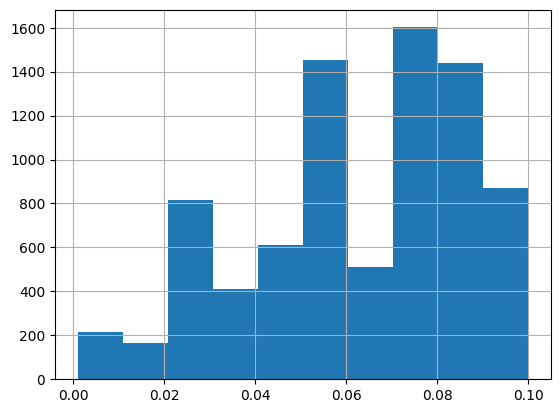

In [7]:
df_class['Z_TONRY'].hist(bins = 10) # bin is essentially intervals 

In [8]:
c = 299792

df_class['Velocity'] = df_class['Z_TONRY'] * 299792 #creates new column that takes redshift value x speed of light

df_class['Dist'] = 10**((df_class['DM_70_25_75']+5)/5) * 10**-6 # converts distance modulus to dist in Mpc

df_class

,CATAID,RA,DEC,NQ,Z_TONRY,DM_70_25_75,Velocity,Dist
0,6729,173.70055,0.77608,5,0.051504,36.8029,15440.487168,229.392915
1,6768,173.85337,0.62975,5,0.076044,37.6886,22797.352869,344.921289
2,6822,174.15365,0.81688,5,0.004229,31.2961,1267.931291,18.164356
3,6826,174.18493,0.70906,5,0.074050,37.6278,22199.687538,335.397638
4,6844,174.39605,0.82075,5,0.098669,38.2896,29580.266786,454.904256
...,...,...,...,...,...,...,...,...
8085,4291856,138.50641,0.46007,5,0.001063,28.2925,318.549985,4.555122
8086,4293313,140.13494,0.55828,5,0.001012,28.1874,303.503425,4.339903
8087,4331358,130.13719,-0.08028,5,0.001399,28.8897,419.310077,5.997082
8088,4335633,133.54893,-0.11025,5,0.001075,28.3182,322.351348,4.609353


<Axes: xlabel='Dist', ylabel='Velocity'>

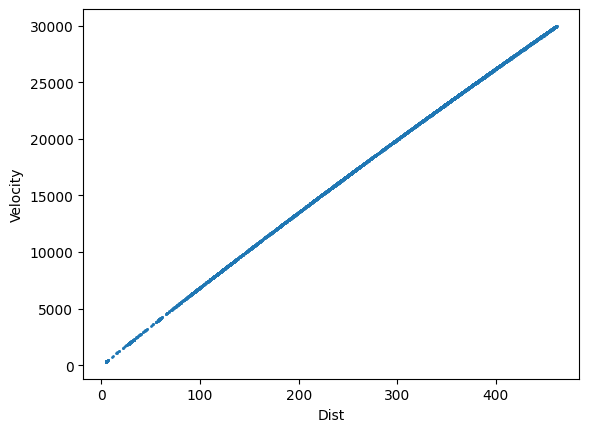

In [ ]:
df_class.plot.scatter(x='Dist', y='Velocity', s = 1) # s is to  change the size of the marker 

In [ ]:
def func(x,a): # where a is hubble constant
    return x*a

blah = curve_fit(func, df_class['Dist'], df_class['Velocity'])
hubble = blah[0]
hubble


array([66.01107321])

<Axes: title={'center': 'V = H*d'}, xlabel='Dist', ylabel='Velocity'>

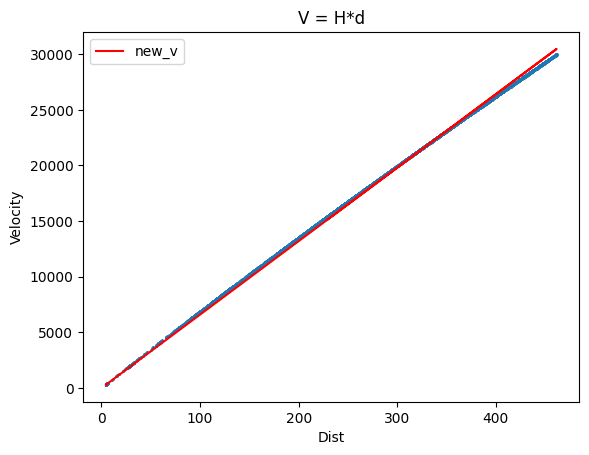

In [ ]:
df_class['new_v'] = df_class['Dist']*hubble # predicted velocity, found using regression line
ax = df_class.plot(x='Dist', y='Velocity',kind= 'scatter', s = 1, title= 'V = H*d') # experimental scatter
df_class.plot(x= 'Dist', y= 'new_v', c='red', ax=ax, kind = 'line') # regression line

In [39]:
hubble_s = hubble/(3.086*10**19) #converts Mpc to km, so the km cancels out, leaving hubble with s^-1
t_uni_s = 0.956/hubble_s # time of uni in secs
t_uni_years = t_uni_s * (3.17098*10**-8) # time of uni in years
t_uni_billionyears = t_uni_years / 10**9 # time of uni in billion years
print(t_uni_billionyears)

age_of_uni = 13.787
percentage_diff = ((t_uni_billionyears - age_of_uni) / age_of_uni) * 100
print(percentage_diff)

[14.17197976]
[2.79233884]
